In [2]:
import pandas as pd

In [3]:
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip

In [4]:
!unzip -o smsspamcollection.zip


Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [5]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

In [8]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [11]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [12]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [13]:
print(df["label"].value_counts(normalize=True) * 100)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


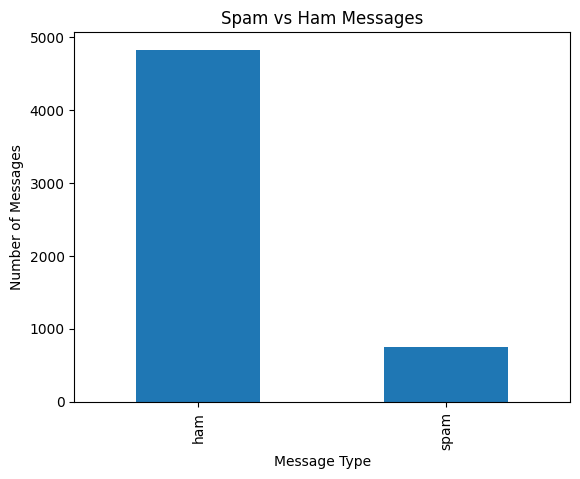

In [14]:
df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [15]:
import nltk
import string
import re

nltk.download("stopwords")

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [16]:
stop_words = set(stopwords.words("english"))

In [17]:
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words again
    text = " ".join(words)

    return text

In [18]:
df["clean_message"] = df["message"].apply(clean_text)

In [19]:
df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_message"])

In [22]:
print(X.shape)

(5572, 8501)


## TF-IDF

TF-IDF stands for Term Frequency-Inverse Document Frequency.

Machine learning models cannot directly understand text, so TF-IDF converts text into numerical features.

Term Frequency measures how often a word appears in a message, while Inverse Document Frequency gives less importance to words that appear in many messages.

Therefore, TF-IDF helps the machine learning model identify words that are useful for distinguishing spam messages from legitimate messages.

In [23]:
y = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [24]:
print(y.head())

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
from sklearn.naive_bayes import MultinomialNB

In [29]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [30]:
nb_predictions = nb_model.predict(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
lr_predictions = lr_model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [35]:
print("NAIVE BAYES")

print("Accuracy:", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions))
print("Recall:", recall_score(y_test, nb_predictions))
print("F1 Score:", f1_score(y_test, nb_predictions))

NAIVE BAYES
Accuracy: 0.9632286995515695
Precision: 1.0
Recall: 0.7248322147651006
F1 Score: 0.8404669260700389


In [36]:
print("LOGISTIC REGRESSION")

print("Accuracy:", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))
print("F1 Score:", f1_score(y_test, lr_predictions))

LOGISTIC REGRESSION
Accuracy: 0.9587443946188341
Precision: 1.0
Recall: 0.6912751677852349
F1 Score: 0.8174603174603174


In [37]:
from sklearn.metrics import confusion_matrix

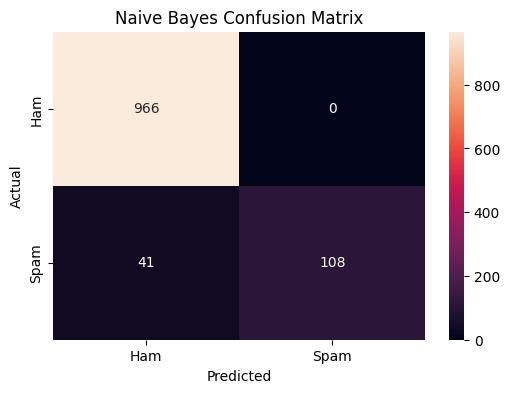

In [38]:
cm = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

## Why is Recall Important in Spam Detection?

Recall is important because it measures how many of the actual spam messages are correctly detected by the model.

If a spam message is incorrectly classified as a legitimate message, it becomes a false negative. This means the spam message may reach the user's inbox.

Therefore, recall is an important metric for spam detection because we want to detect as many actual spam messages as possible.

In [39]:
!pip install wordcloud

In [40]:
from wordcloud import WordCloud

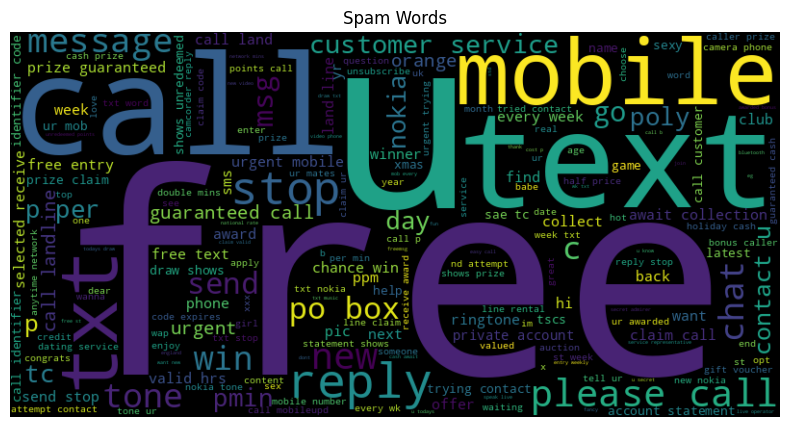

In [41]:
spam_text = " ".join(
    df[df["label"] == "spam"]["clean_message"]
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Spam Words")

plt.show()

In [42]:
def predict_message(message):

    cleaned_message = clean_text(message)

    message_vector = vectorizer.transform([cleaned_message])

    prediction = nb_model.predict(message_vector)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [43]:
message = "Congratulations! You won a free prize. Click now!"

print(predict_message(message))

SPAM


In [44]:
message = "Hey, are you coming to college tomorrow?"

print(predict_message(message))

HAM


## Conclusion

In this project, we developed an SMS spam detection system using Natural Language Processing and Machine Learning.

The messages were cleaned using lowercase conversion, punctuation removal, number removal, and stopword removal.

TF-IDF was used to convert the text into numerical features. Two classification algorithms, Multinomial Naive Bayes and Logistic Regression, were trained.

The models were evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The system can also predict whether a new message is spam or ham.